cpu


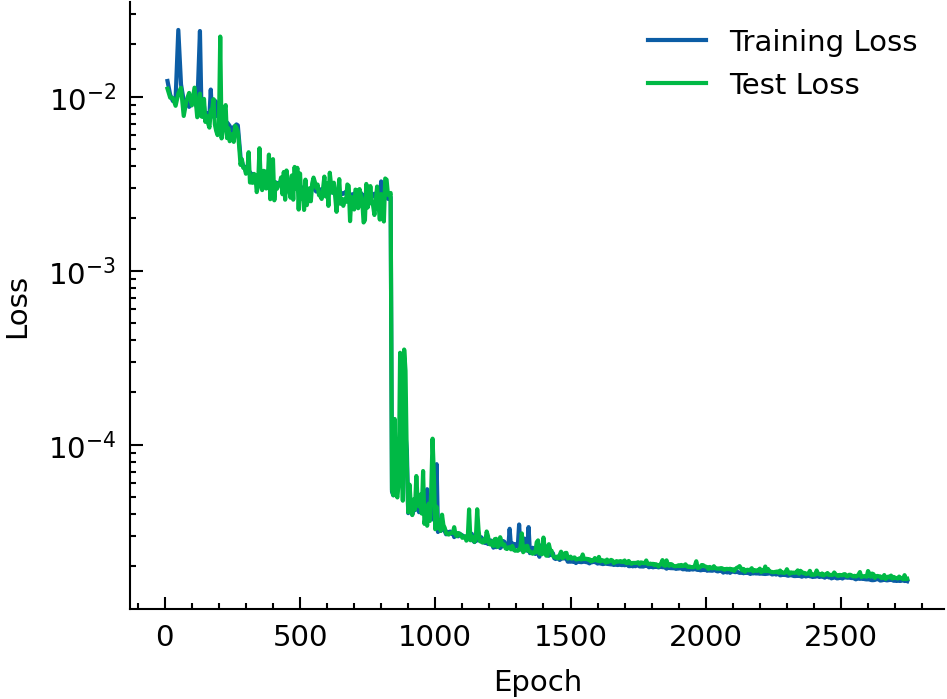

In [1]:
%reset -f

import torch
from plpm import numerical_solver, calculate_PLV
from plpm import ModelWrapper, MainPlots

space_dim = 10
model_file = 'MainModel10D'

main_model = ModelWrapper.Model(model_file=model_file, d=space_dim)

loss_file = 'losses10D'

figures = MainPlots()
figures.plot_loss(loss_file)


In [2]:
# Defining the case
mR_av, mR_ao, mC_ao, mR_art, mC_art = torch.tensor([1., 1., 1., 1., 1.])  # Multipliers
mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv = torch.tensor([1., 1., 1., 1., 1.])

CASE = torch.tensor([[mR_av, mR_ao, mC_ao, mR_art, mC_art,
                      mR_vc, mC_vc, mR_mv, mEes_lv, mtrans_lv]])

In [3]:
# Calculating the numerical solution
V_num = numerical_solver(CASE, dt=0.5, n_cycle=30)
plv_num = calculate_PLV(V_num[:, 0], mEes_lv, mtrans_lv)

Steady State Solution
Elapsed Time:  9.3679940700531 seconds


In [4]:
# Estimating with the trained pinn, if the dimension of the model is not 10,
# CASE should be modified accordingly.
V_pinn = main_model.predict_CASE(CASE, num_timepoints=801)
plv_pinn = calculate_PLV(V_pinn[:, 0], mEes_lv, mtrans_lv)

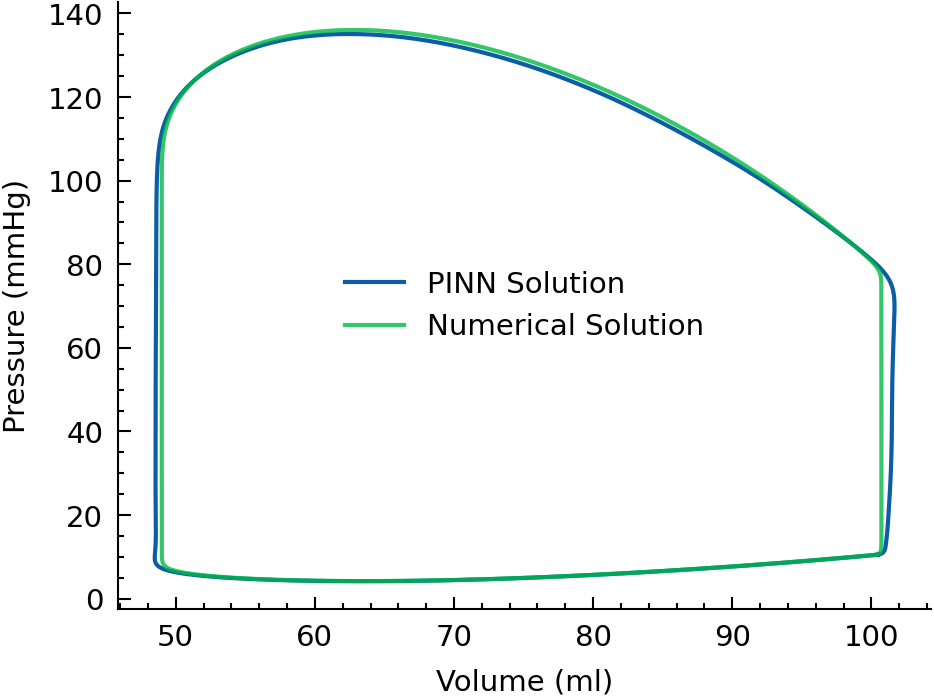

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(V_pinn[:, 0], plv_pinn, label='PINN Solution')
ax.set_xlabel('Volume (ml)')
ax.set_ylabel('Pressure (mmHg)')
ax.plot(V_num[:, 0], plv_num, label='Numerical Solution', alpha=0.8)
ax.legend()
plt.show(fig)

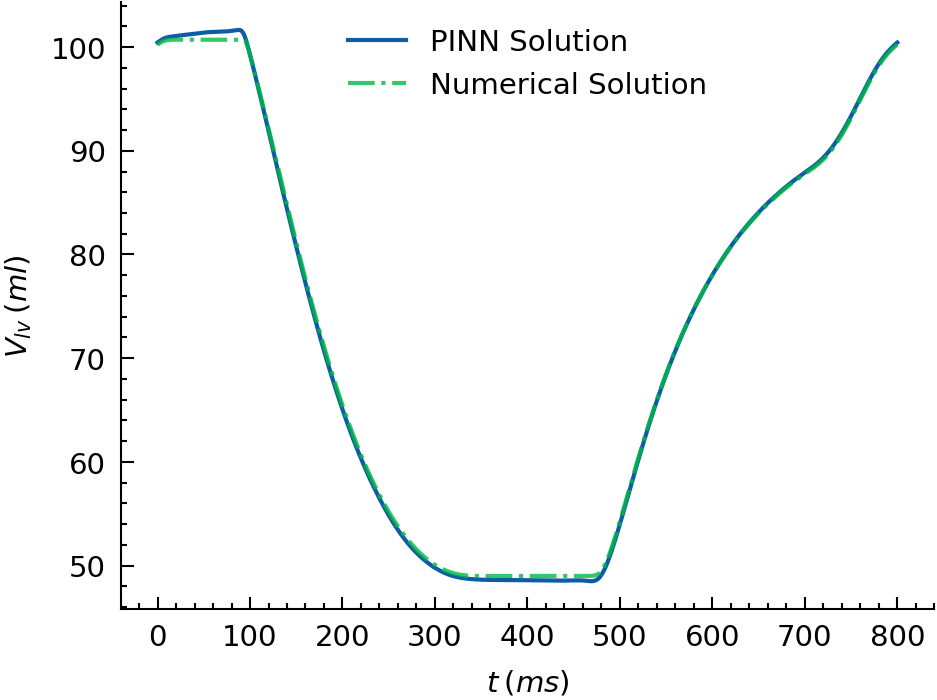

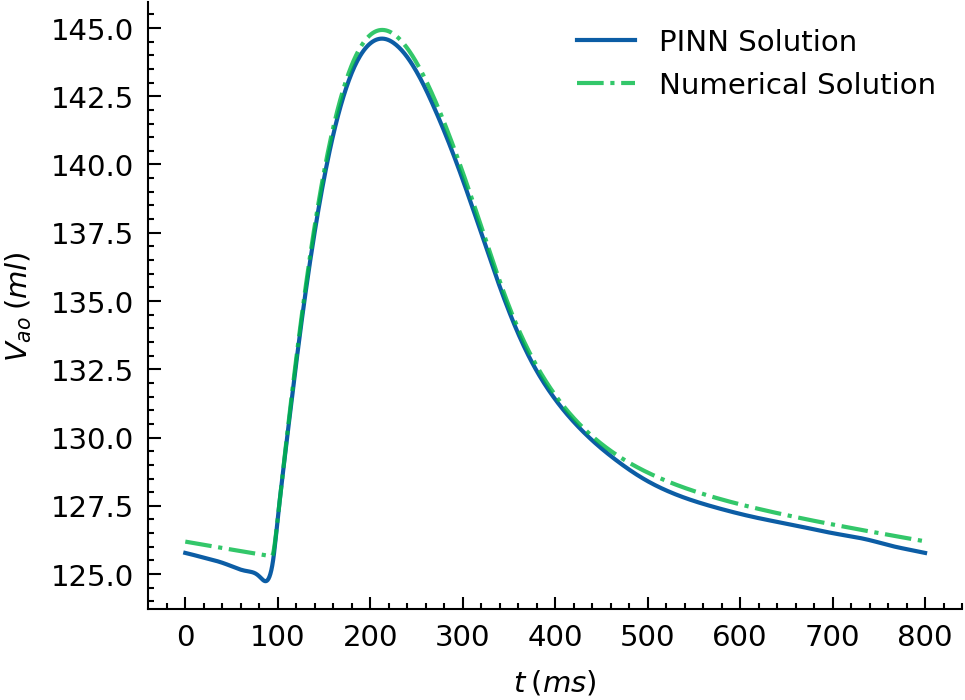

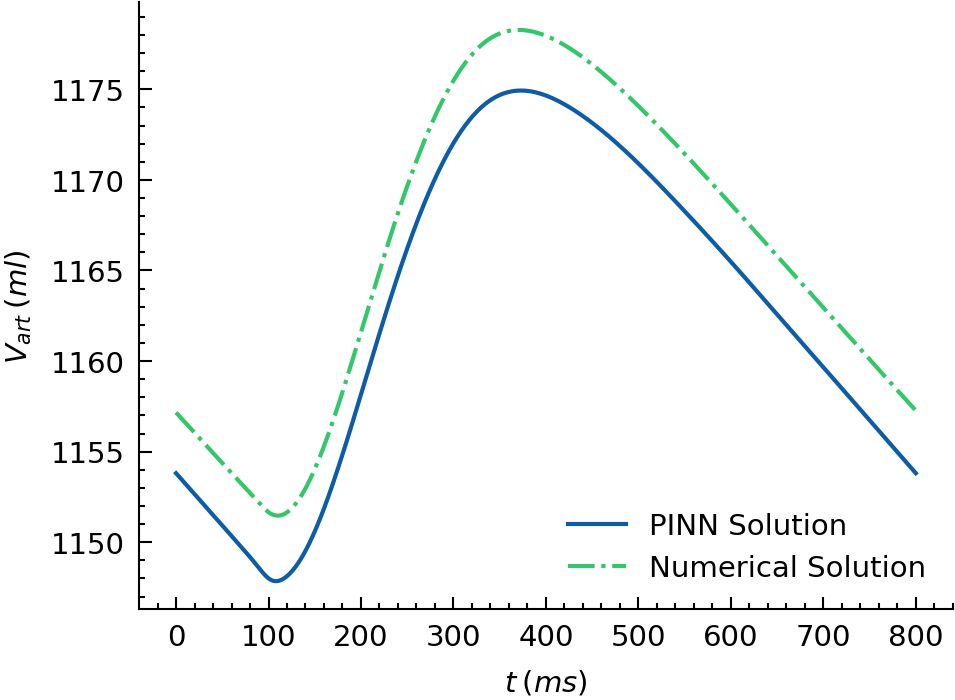

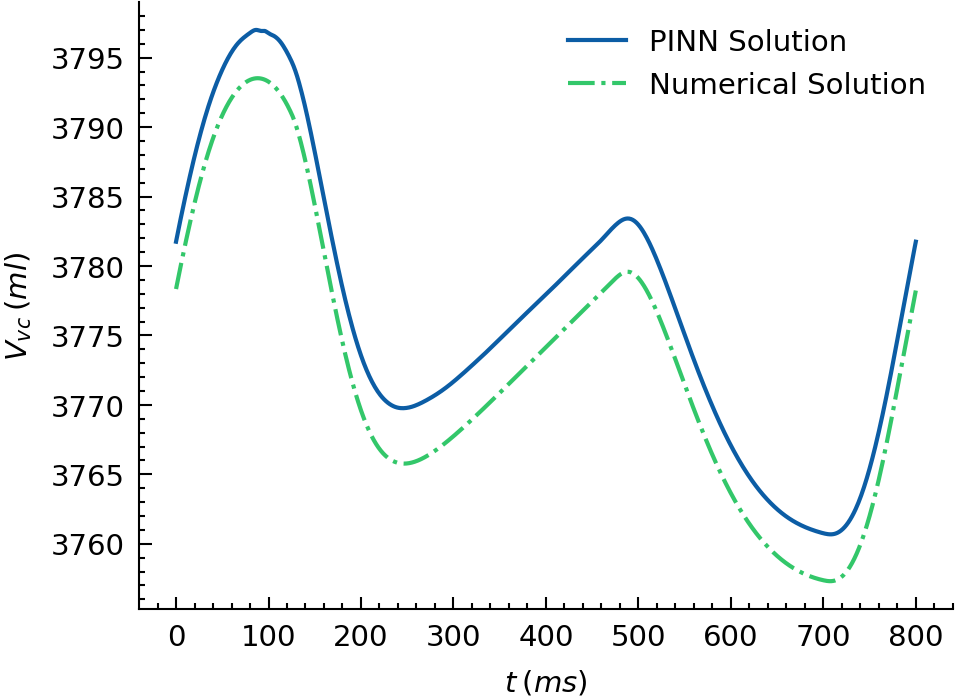

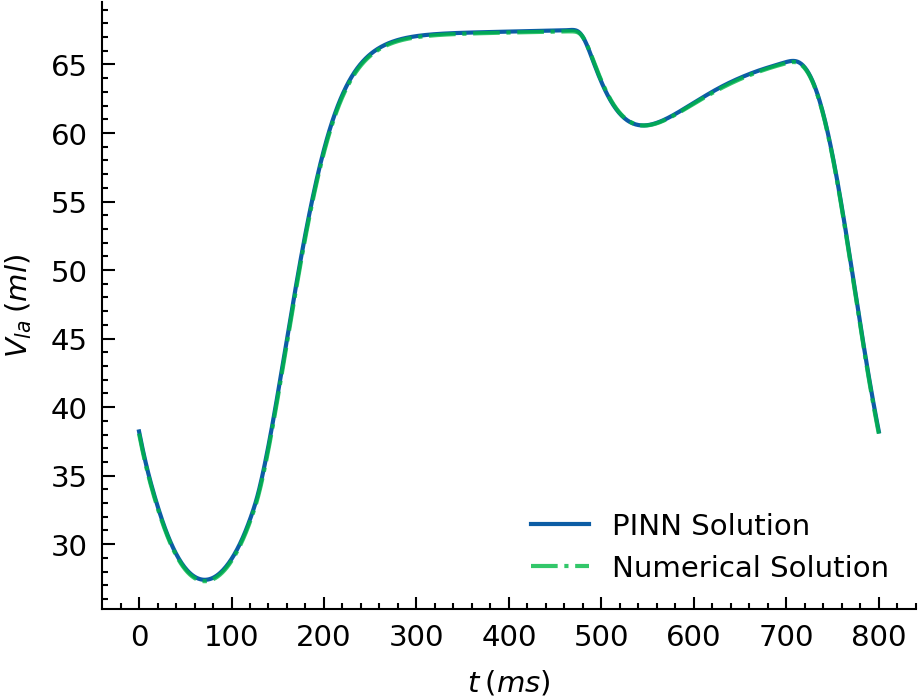

In [6]:
figures.plot_CASE_seperate(V_pinn=V_pinn, V_numerical=V_num)

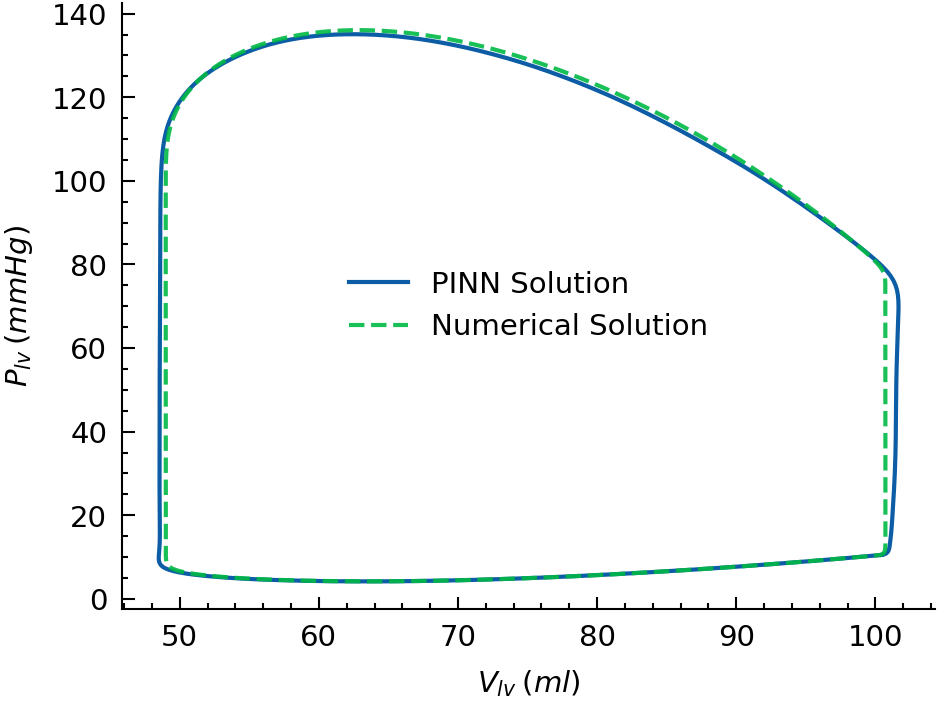

In [7]:
figures.plot_PVloop(V_pinn[:, 0], plv_pinn, V_num[:, 0], plv_num)

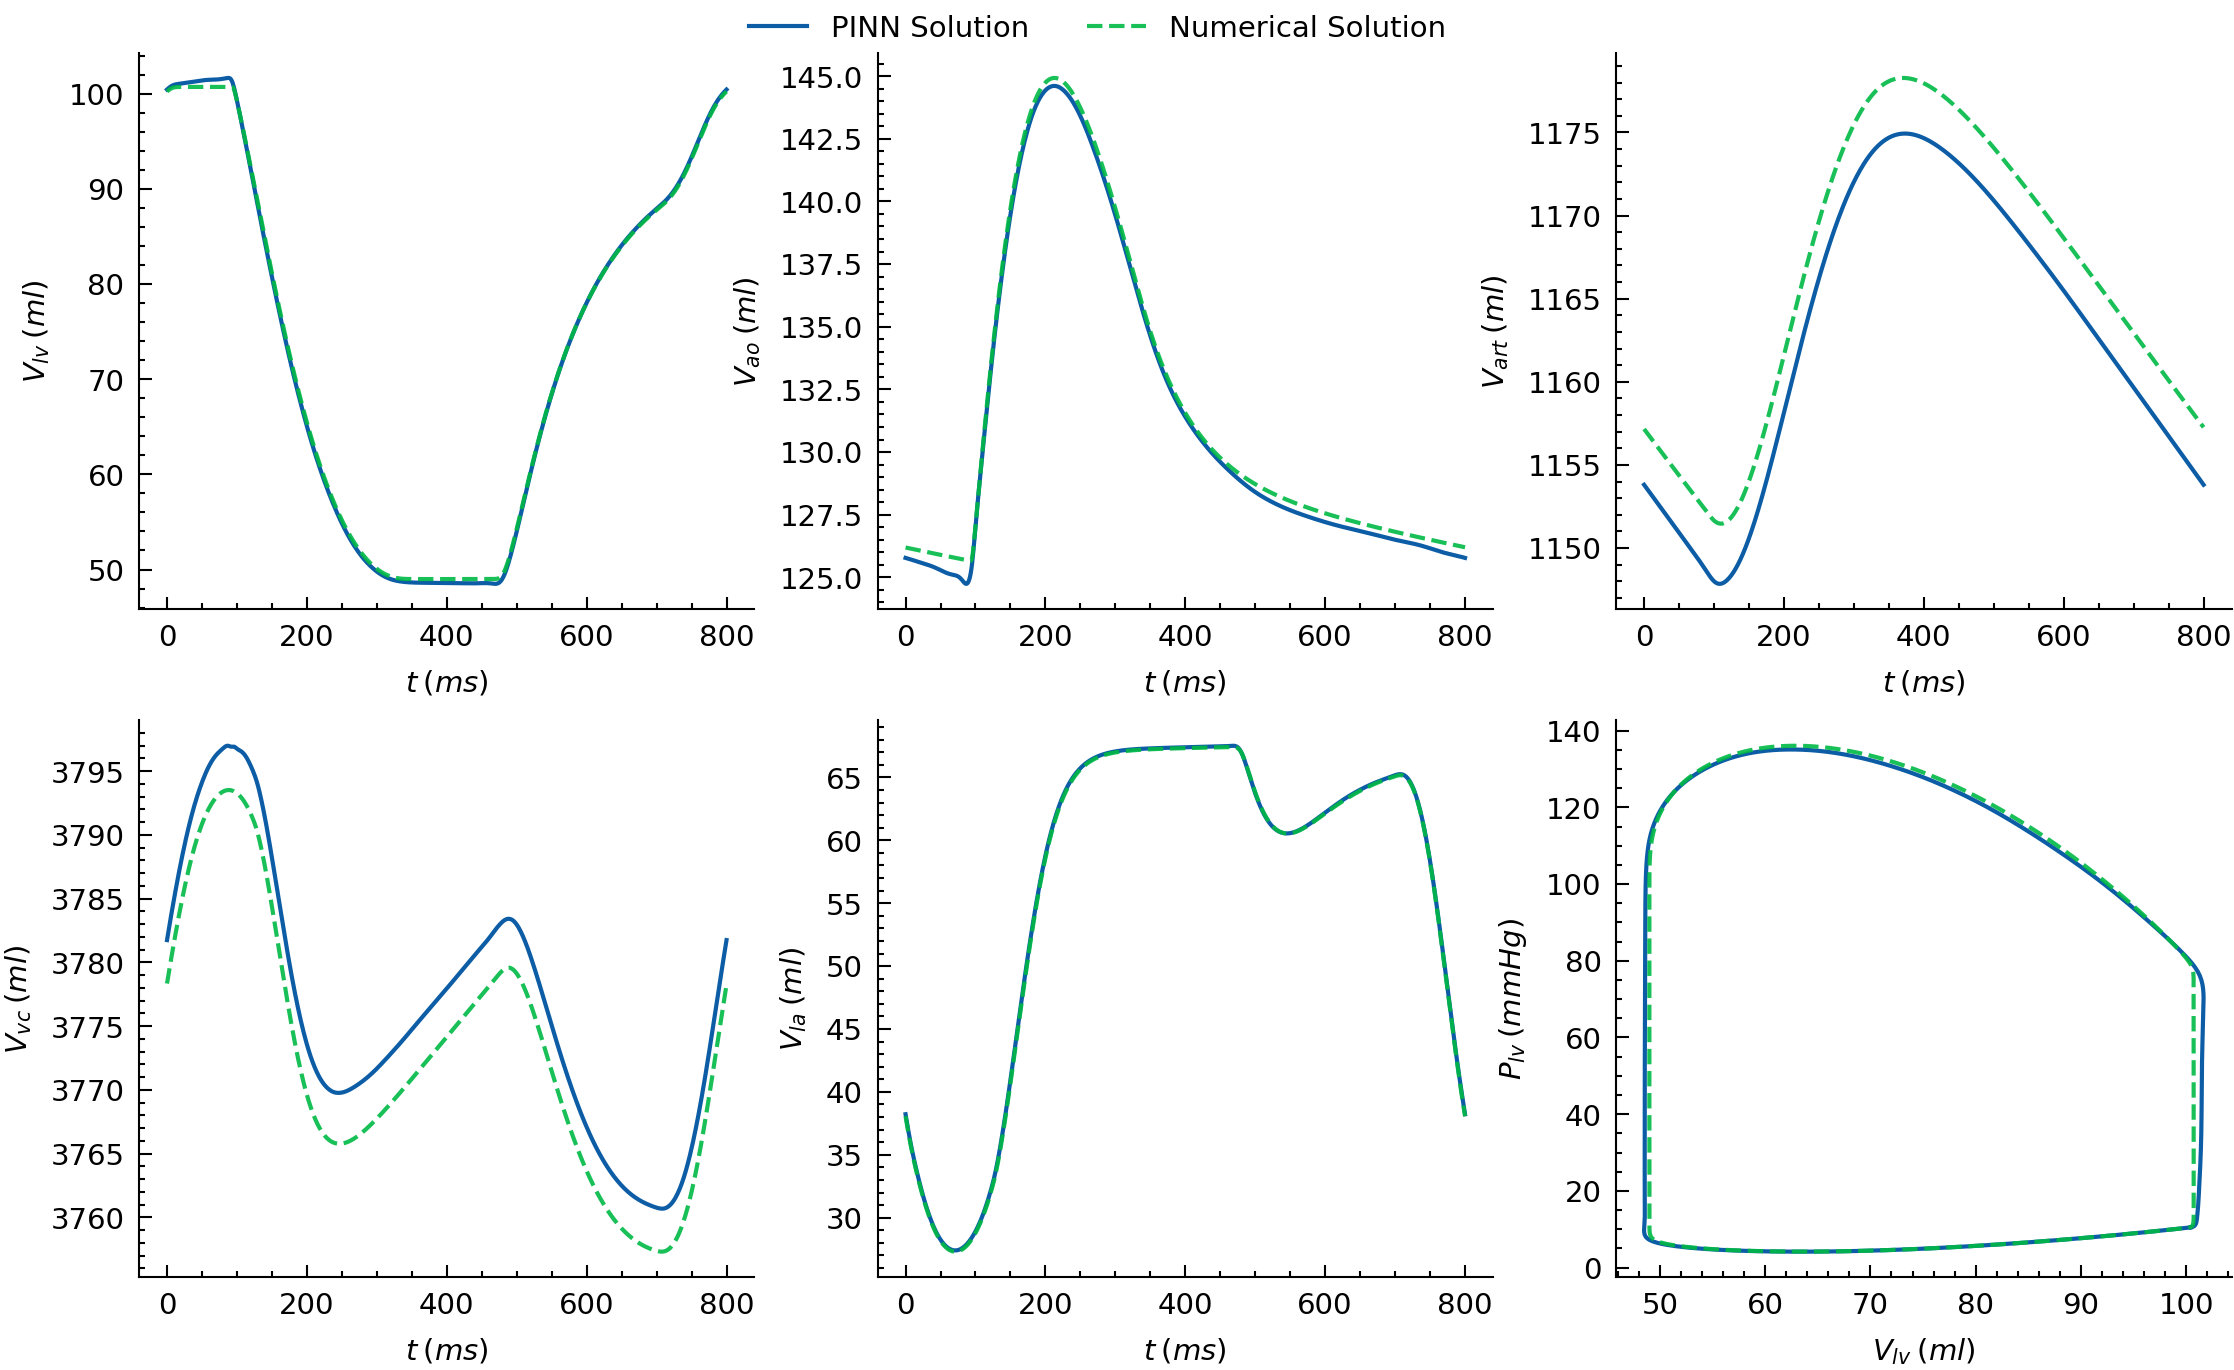

In [8]:
figures.plot_CASE_together(V_pinn, plv_pinn, V_num, plv_num)